# 07 · Sea-level rise and the meaning of a 3D scene

**Time:** 40 minutes · **Audience:** undergraduate / introductory graduate GIS and Earth science.

**By the end:** Build a terrain-like scene, test height thresholds, and identify missing physical processes.

[Run in JupyterLite](https://jltobias.github.io/JupyterLite-zarr-sql-views/lite/lab/index.html?path=07_coastal_scenes.ipynb) · [Earth lab](https://jltobias.github.io/JupyterLite-zarr-sql-views/lab/) · [Sources and licenses](https://jltobias.github.io/JupyterLite-zarr-sql-views/book/credits.html)

Run cells from top to bottom with **Shift+Enter**. The first kernel start downloads Python WebAssembly packages.
The bundled exercises need no data-service account. Save a copy with **File → Save and Export Notebook As** before clearing browser storage.

![Four-stage workflow: STAC discovery, Zarr reading, SQL selection, linked views](assets/pipeline.svg)

In [1]:
from course import *
import numpy as np
import matplotlib.pyplot as plt
print('Ready: Python + NumPy + local teaching data')

Ready: Python + NumPy + local teaching data


## 1. Read the synthetic terrain

Coordinates place an invented grid near Durban for geographic orientation only. Elevations are analytic, not a measured DEM.
The vertical zero has no surveyed datum. A threshold at 1 m is an experiment, not a sea-level projection.
Real inundation requires connected water pathways, defensible elevation and water-level datums, tides, waves, and local defenses.

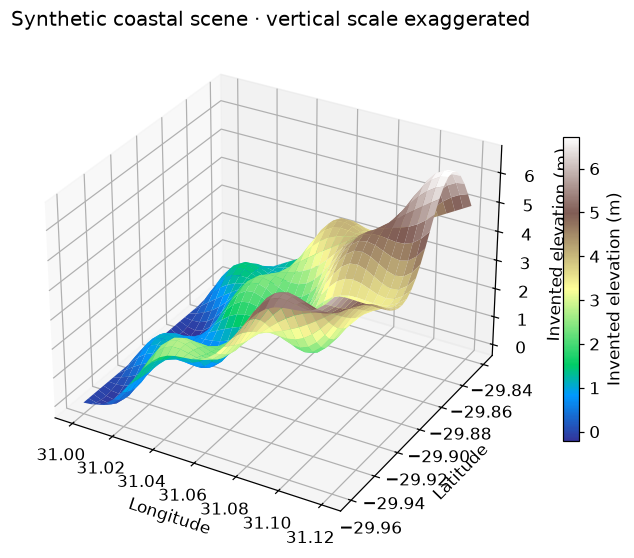

In [2]:
meta,terrain=load_cube('coast')
z=terrain[0]
lon,lat=np.meshgrid(meta['lon'],meta['lat'])
fig=plt.figure(figsize=(9,6));ax=fig.add_subplot(111,projection='3d')
surface=ax.plot_surface(lon,lat,z,cmap='terrain',linewidth=0)
ax.set(xlabel='Longitude',ylabel='Latitude',zlabel='Invented elevation (m)',title='Synthetic coastal scene · vertical scale exaggerated')
fig.colorbar(surface,ax=ax,shrink=.6,label='Invented elevation (m)');plt.show()

## 2. Separate low cells from connected low cells

A flood-fill from the grid’s left edge illustrates connectivity. The edge is stipulated to be water-connected for this toy exercise.
This still omits flow dynamics and all real-world coastal forcing.

In [3]:
from collections import deque
level=1.0
low=z<level
connected=np.zeros_like(low)
queue=deque((y,0) for y in range(z.shape[0]) if low[y,0])
while queue:
    y,x=queue.popleft()
    if connected[y,x]: continue
    connected[y,x]=True
    for yy,xx in [(y-1,x),(y+1,x),(y,x-1),(y,x+1)]:
        if 0<=yy<z.shape[0] and 0<=xx<z.shape[1] and low[yy,xx] and not connected[yy,xx]:
            queue.append((yy,xx))
print('Below threshold:',low.sum(),'Connected to assumed boundary:',connected.sum())
assert np.all(~connected | low)

Below threshold: 215 Connected to assumed boundary: 215


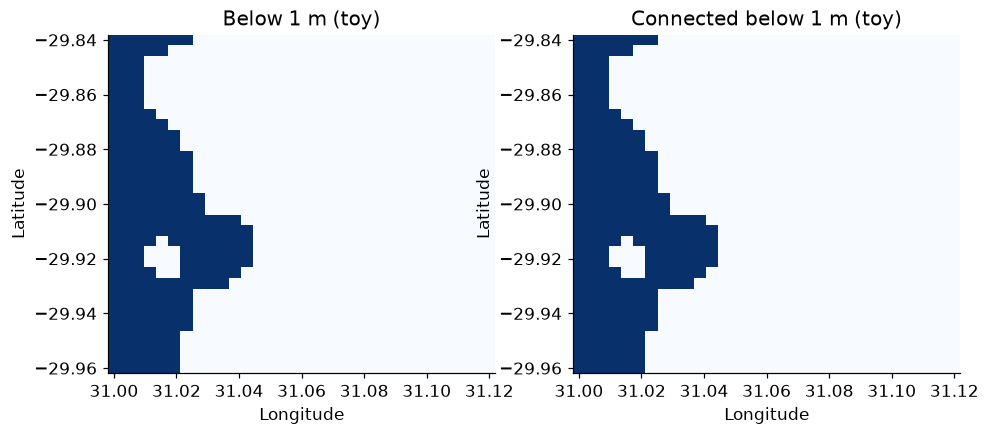

In [4]:
fig,axes=plt.subplots(1,2,figsize=(10,4))
for ax,grid,title in zip(axes,[low,connected],['Below 1 m (toy)','Connected below 1 m (toy)']):
    ax.pcolormesh(meta['lon'],meta['lat'],grid,cmap='Blues',shading='nearest',vmin=0,vmax=1)
    ax.set(title=title,xlabel='Longitude',ylabel='Latitude')
plt.show()

## 3. Explore uncertainty before telling a story

Add ±0.5 m as an arbitrary perturbation to illustrate sensitivity. It is not an estimated DEM error distribution.
If a small perturbation changes many classifications, a precise-looking 3D picture can conceal substantial uncertainty.

In [5]:
for offset in [-.5,0,.5]:
    print('Invented offset:',offset,'m; cells below level:',np.count_nonzero(z+offset<level))
lab('coast','scene')

Invented offset: -0.5 m; cells below level: 317
Invented offset: 0 m; cells below level: 215
Invented offset: 0.5 m; cells below level: 117


## Try it yourself

Increase the height threshold, then specify the minimum metadata needed to replace this scene with a real coastal DEM.

## Check your reasoning

Document vertical and horizontal datums, resolution, acquisition date, terrain versus surface height, uncertainty, and water connectivity. None is established by a smooth rendering.

## Evidence journal

Write four sentences: **what I observed; how I calculated it; what this cannot establish; what evidence I need next**.
For any figure you reuse, retain its units, date or scenario, data origin, transformations, and attribution.

## Sources and credit

- [IPCC AR6 WGII, Chapter 9: Africa](https://www.ipcc.ch/report/ar6/wg2/chapter/chapter-9/). Linked context, not redistributed data.
- [IPCC AR6 WGI, Chapter 9: Ocean, Cryosphere and Sea Level Change](https://www.ipcc.ch/report/ar6/wg1/chapter/chapter-9/)

Teaching adaptation of [dzole0311/zarr-sql-views](https://github.com/dzole0311/zarr-sql-views), ISC.
Original teaching code and prose: JupyterLite-zarr-sql-views contributors, ISC. Data keep their separate licenses.